In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Arial'

In [2]:
df = pd.read_csv('../data/linarg_plink_prs_runtime.tsv', sep='\t')
linarg_time = df[df.method=='linarg'].runtime.iloc[0]
plink_time = np.sum(df[df.method=='plink'].runtime)
print(linarg_time, plink_time)
df

17.86 662.9399999999999


,method,node,region,dataset,runtime,peak_mem
0,linarg,mem3_ssd1_v2_x32,chr1-22,common,17.86,2556.89
1,plink,mem3_ssd1_v2_x32,chr1,common,47.65,3907.88
2,plink,mem3_ssd1_v2_x32,chr2,common,52.90,3990.87
3,plink,mem3_ssd1_v2_x32,chr3,common,53.65,3924.05
4,plink,mem3_ssd1_v2_x32,chr4,common,46.01,3916.57
5,plink,mem3_ssd1_v2_x32,chr5,common,40.83,3901.06
6,plink,mem3_ssd1_v2_x32,chr6,common,43.78,3892.68
7,plink,mem3_ssd1_v2_x32,chr7,common,37.91,3919.56
8,plink,mem3_ssd1_v2_x32,chr8,common,36.36,3968.52
9,plink,mem3_ssd1_v2_x32,chr9,common,30.29,3846.19


/var/folders/75/tn_w8_tx70dfp53nnb6hyk6h0000gn/T/ipykernel_28367/3379829118.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(methods, fontsize=18)


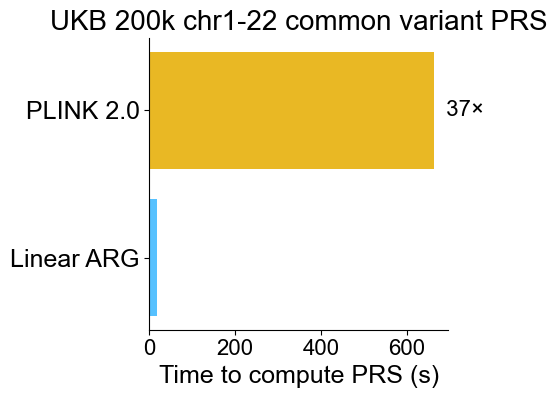

In [3]:
colors = {
    'Linear ARG': '#56C1FF', # blue
    'PLINK 2.0': '#E9B824', # yellow
}

methods = ['Linear ARG', 'PLINK 2.0']
times = [linarg_time, plink_time]
ratios = [round(t / plink_time, 1) for t in times]

fig, ax = plt.subplots(figsize=(5, 4))
for i in range(len(methods)):
    ax.barh(methods[i], times[i], color=colors[methods[i]])
    
for i in range(len(methods)):
    if methods[i] == 'Linear ARG':
        continue
    speedup = times[i] / linarg_time
    ax.text(times[i] + 0.05, i, f"  {int(speedup)}×", va='center', fontsize=16)
    

ax.set_yticklabels(methods, fontsize=18)
ax.set_xlabel('Time to compute PRS (s)', fontsize=18)
ax.set_title('UKB 200k chr1-22 common variant PRS', fontsize=20)
plt.tight_layout()
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.tick_params(axis='x', labelsize=16)
plt.show()